<a href="https://colab.research.google.com/github/leshaz44/Aliaksei/blob/main/Task_5/Task_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Пропущенные значения в столбцах:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000432 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 664
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] Start training from score 0.346906
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

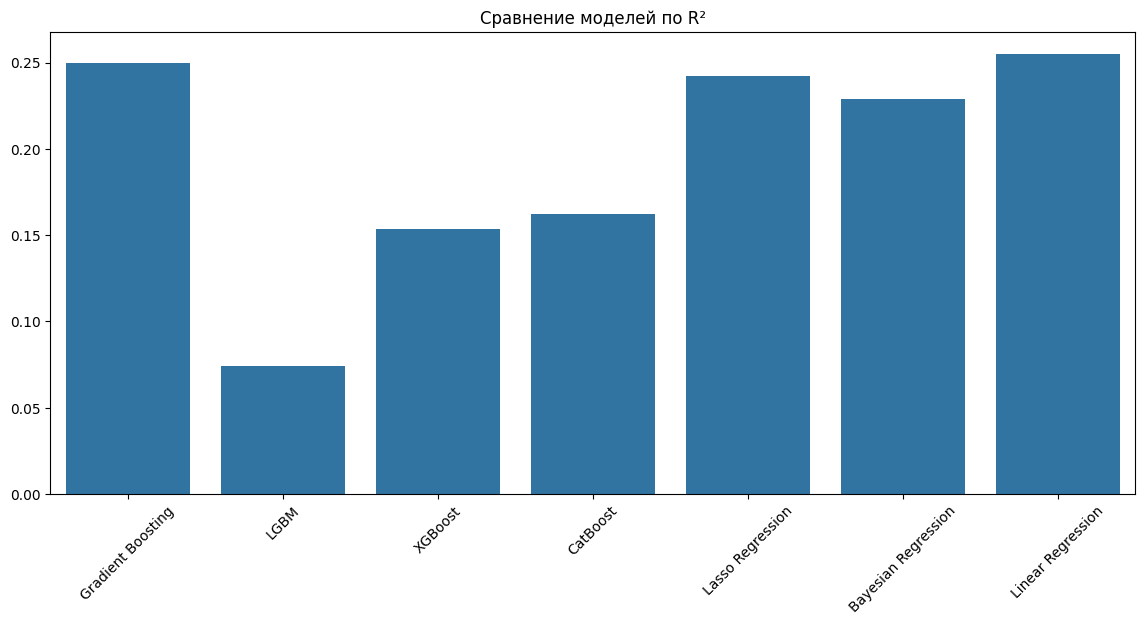

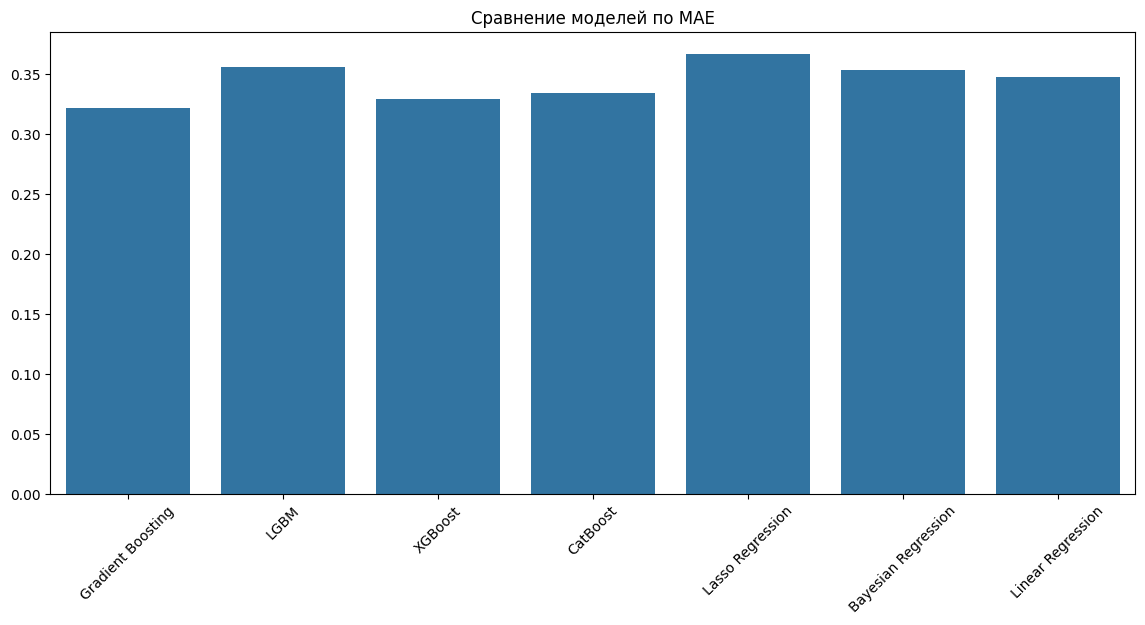

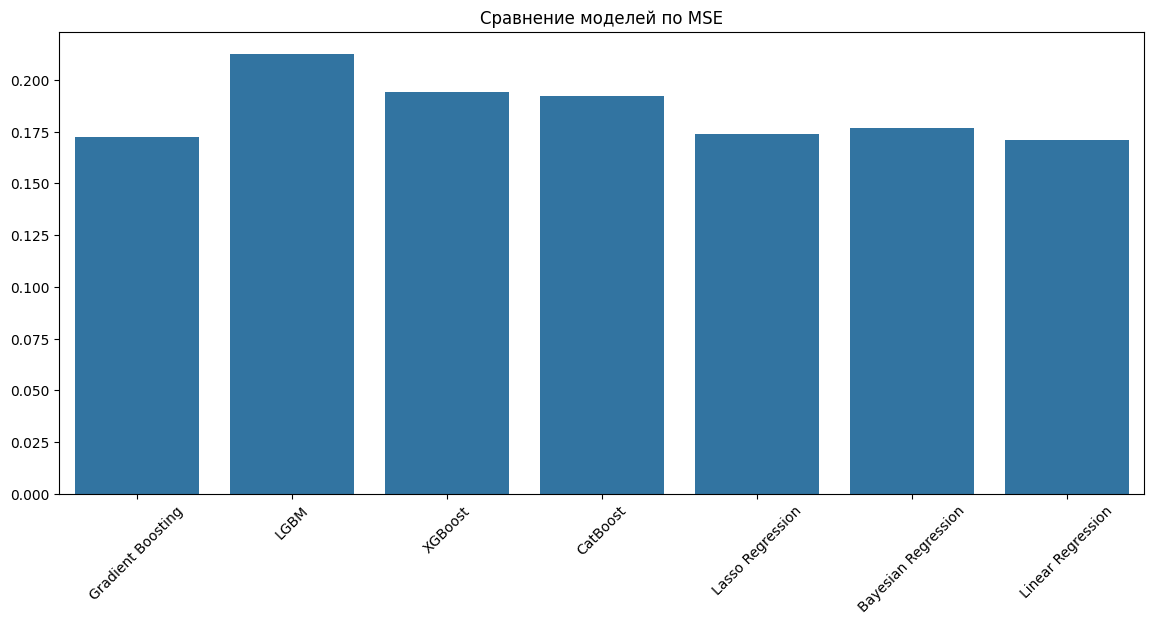

Результаты моделей:
                          MSE       MAE        R2
Gradient Boosting    0.172260  0.321882  0.249713
LGBM                 0.212602  0.356361  0.073999
XGBoost              0.194389  0.329409  0.153329
CatBoost             0.192387  0.334107  0.162050
Lasso Regression     0.174010  0.367006  0.242091
Bayesian Regression  0.176987  0.353543  0.229123
Linear Regression    0.171045  0.348128  0.255003

Лучшая модель: Linear Regression с R² = 0.2550


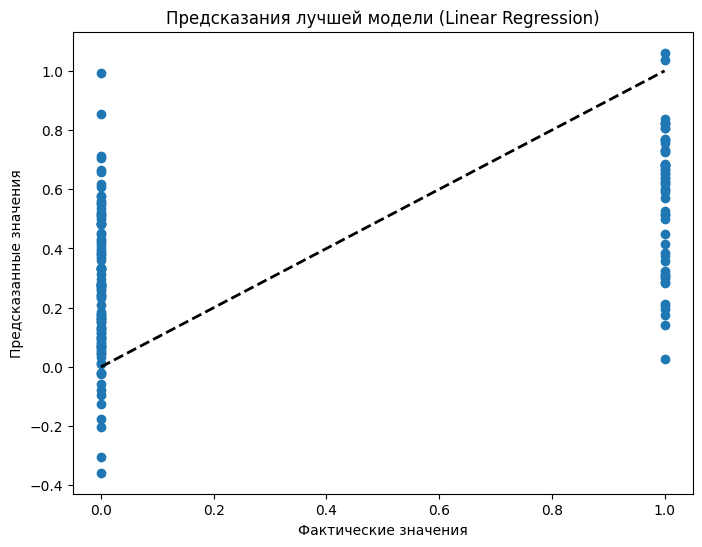

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, Lasso, BayesianRidge
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
data = pd.read_csv('diabetes.csv')

# Анализ пропущенных значений
print("Пропущенные значения в столбцах:")
print(data.isnull().sum())

# Подготовка данных
X = data.drop('Outcome', axis=1)  # Предполагаем, что Outcome - целевая переменная
y = data['Outcome']

# Обработка пропущенных значений
X.fillna(X.mean(), inplace=True)

# Разделение на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Словарь для хранения метрик
results = {}

def evaluate_model(model, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {'MSE': mse, 'MAE': mae, 'R2': r2}
    return y_pred

# Создание моделей
models = {
    'Gradient Boosting': GradientBoostingRegressor(),
    'LGBM': LGBMRegressor(),
    'XGBoost': XGBRegressor(),
    'CatBoost': CatBoostRegressor(verbose=0),
    'Lasso Regression': Lasso(),
    'Bayesian Regression': BayesianRidge(),
    'Linear Regression': LinearRegression()
}

# Обучение и оценка моделей
for name, model in models.items():
    evaluate_model(model, name)

# Визуализация результатов
plt.figure(figsize=(14, 6))
sns.barplot(x=list(results.keys()), y=[v['R2'] for v in results.values()])
plt.title('Сравнение моделей по R²')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(14, 6))
sns.barplot(x=list(results.keys()), y=[v['MAE'] for v in results.values()])
plt.title('Сравнение моделей по MAE')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(14, 6))
sns.barplot(x=list(results.keys()), y=[v['MSE'] for v in results.values()])
plt.title('Сравнение моделей по MSE')
plt.xticks(rotation=45)
plt.show()

# Вывод результатов
results_df = pd.DataFrame(results).T
print("Результаты моделей:")
print(results_df)

# Определение лучшей модели
best_model_name = results_df['R2'].idxmax()
print(f"\nЛучшая модель: {best_model_name} с R² = {results_df.loc[best_model_name, 'R2']:.4f}")

# График предсказаний лучшей модели
best_model = models[best_model_name]
best_pred = evaluate_model(best_model, best_model_name)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title(f'Предсказания лучшей модели ({best_model_name})')
plt.show()